In [61]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

Dataset: 300K Student Performance Prediction Dataset

Dataset Link: https://www.kaggle.com/datasets/rhythmghai/300k-student-performance-prediction-dataset


In [62]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Datasets/student_performance_prediction_dataset-2.csv'
data = pd.read_csv(drive_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
data.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [64]:
data.shape

(300000, 25)

In [65]:
data.columns

Index(['student_id', 'age', 'gender', 'study_hours', 'attendance',
       'sleep_hours', 'previous_grade', 'assignments_completed',
       'practice_tests_taken', 'group_study_hours', 'notes_quality_score',
       'time_management_score', 'motivation_level', 'mental_health_score',
       'screen_time', 'social_media_hours', 'family_income',
       'parent_education', 'internet_access', 'device_type', 'school_type',
       'extracurriculars', 'final_grade', 'grade_category', 'pass_fail'],
      dtype='object')

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [67]:
data.device_type.fillna('Missing', inplace=True)
data.extracurriculars.fillna('Missing', inplace=True)

/tmp/ipykernel_724/2328358432.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.device_type.fillna('Missing', inplace=True)
/tmp/ipykernel_724/2328358432.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [68]:
#data.dropna(subset=['grade_category'], axis=0, inplace=True)

In [69]:
#data = data.reset_index(drop=True)

In [70]:
data.duplicated().sum()

np.int64(0)

In [71]:
X = data.drop(columns=['pass_fail', 'final_grade', 'grade_category', 'student_id'], axis=1)
y = data['pass_fail']

In [72]:
obj_col = X.select_dtypes('object').columns.tolist()

In [73]:
ohe = OneHotEncoder(sparse_output=False)
ohe_data = ohe.fit_transform(X[obj_col])

In [74]:
ohe_data_f = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out())

In [75]:
X =  pd.concat([X, ohe_data_f], axis=1).drop(columns=obj_col, axis=1)

In [76]:
le = LabelEncoder()
y = le.fit_transform(y)

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [79]:
X_train.shape

(240000, 38)

In [80]:
X_val = X_train[:100000]
partial_X_train = X_train[100000:]
y_val = y_train[:100000]
partial_y_train = y_train[100000:]

In [81]:
activation_list = ['relu', 'tanh']
model_histories = {}

for act in activation_list:
    print(f"\n--- Training for {act.upper()} Activation ---")

    # Model architecture definition
    temp_model = Sequential([
        Input(shape=(X_train.shape[1],)),  # Clean 38 features input
        Dense(64, activation=act),
        Dense(32, activation=act),
        Dense(16, activation=act),
        Dense(1, activation='sigmoid')
    ])

    # Model compilation
    temp_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Model training & history saving
    history = temp_model.fit(
        partial_X_train,
        partial_y_train,
        epochs=10,
        batch_size=125,
        validation_data=(X_val, y_val),
        verbose=1
    )

    # Save history dictionary
    model_histories[act] = history


--- Training for RELU Activation ---
Epoch 1/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8514 - loss: 0.3204 - val_accuracy: 0.8682 - val_loss: 0.2903
Epoch 2/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8690 - loss: 0.2884 - val_accuracy: 0.8684 - val_loss: 0.2888
Epoch 3/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8699 - loss: 0.2861 - val_accuracy: 0.8694 - val_loss: 0.2865
Epoch 4/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8705 - loss: 0.2847 - val_accuracy: 0.8689 - val_loss: 0.2873
Epoch 5/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8710 - loss: 0.2836 - val_accuracy: 0.8687 - val_loss: 0.2885
Epoch 6/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8708 - loss: 0.2831 - val_accuracy: 0.8689 - val_loss: 0.2873
Epoch 7/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8713 - loss: 0.2821 - val_accuracy: 0.8689 - val_loss: 0.2885
Epoch 8/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/st

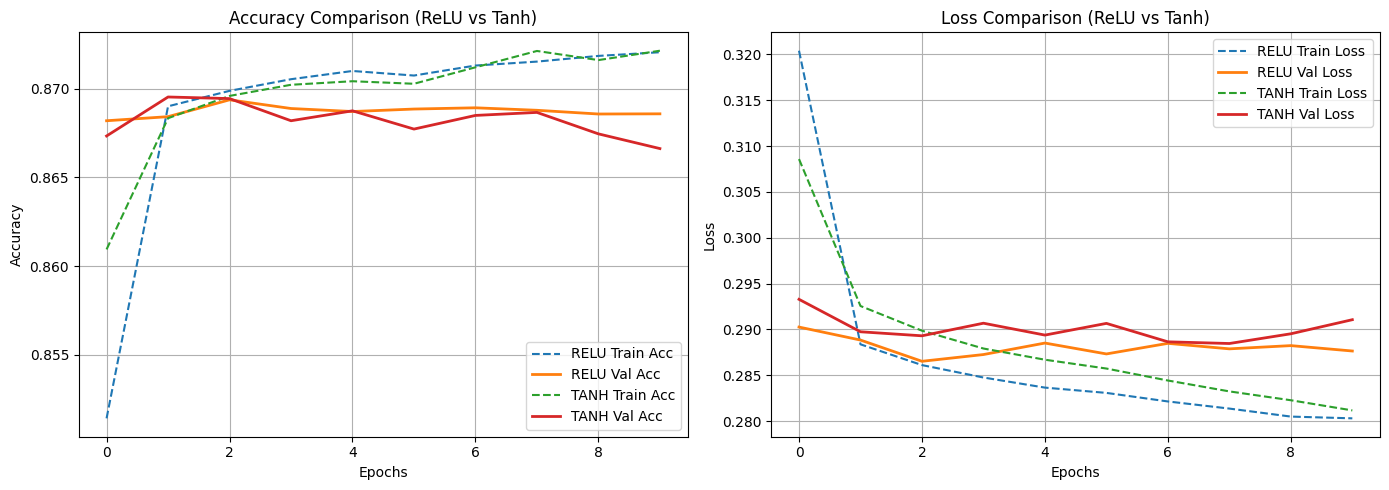

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Training & Validation Accuracy Plot
plt.subplot(1, 2, 1)
for act, hist in model_histories.items():
    plt.plot(hist.history['accuracy'], label=f'{act.upper()} Train Acc', linestyle='--')
    plt.plot(hist.history['val_accuracy'], label=f'{act.upper()} Val Acc', linewidth=2)
plt.title('Accuracy Comparison (ReLU vs Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Training & Validation Loss Plot
plt.subplot(1, 2, 2)
for act, hist in model_histories.items():
    plt.plot(hist.history['loss'], label=f'{act.upper()} Train Loss', linestyle='--')
    plt.plot(hist.history['val_loss'], label=f'{act.upper()} Val Loss', linewidth=2)
plt.title('Loss Comparison (ReLU vs Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [83]:
def create_model():
  return Sequential([Dense(64, activation='relu', input_shape=(38,)),
                    Dense(32, activation='relu'),
                    Dense(16, activation='relu'),
                    Dense(1, activation='sigmoid')])

# 2. Train with Adam
model_adam = create_model()
model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(partial_X_train, partial_y_train, epochs=10, batch_size=125, validation_data=(X_val, y_val), verbose=0)

# 3. Train with SGD
model_sgd = create_model()
model_sgd.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(partial_X_train, partial_y_train, epochs=10, batch_size=125, validation_data=(X_val, y_val), verbose=0)

# 4. Train with RMSprop
model_rmsprop = create_model()
model_rmsprop.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop = model_rmsprop.fit(partial_X_train, partial_y_train, epochs=10, batch_size=125, validation_data=(X_val, y_val), verbose=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


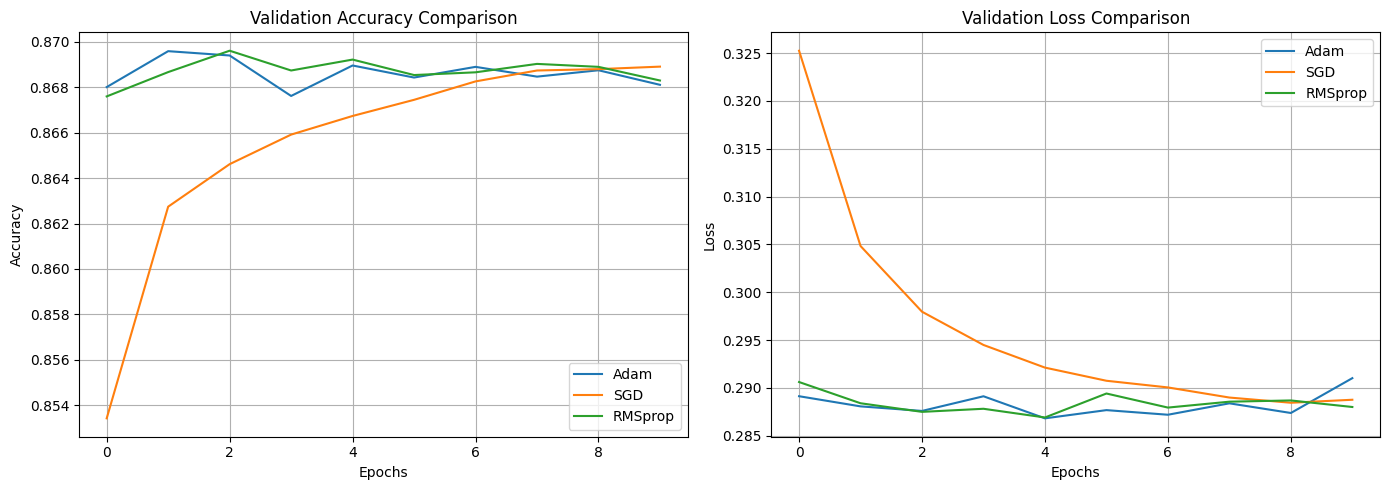

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Validation Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_rmsprop.history['val_loss'], label='RMSprop')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Training for 20 Epochs ---

--- Training for 50 Epochs ---

--- Training for 100 Epochs ---


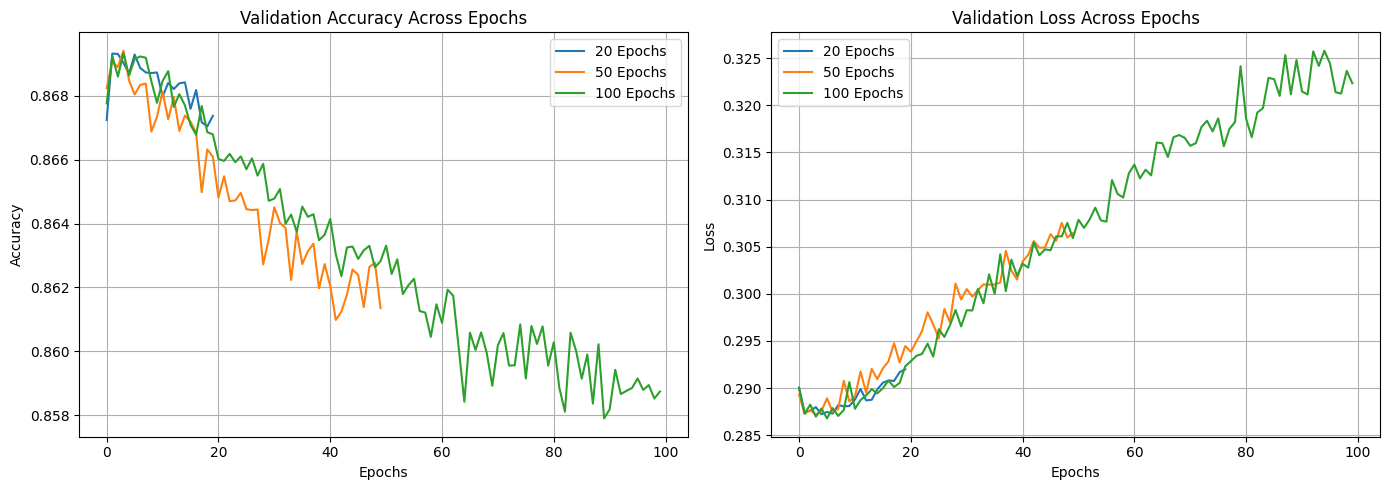

In [85]:
import matplotlib.pyplot as plt

# 1. Models ko alag-alag Epochs par train karein
epochs_list = [20, 50, 100]
histories = {}

for ep in epochs_list:
    print(f"\n--- Training for {ep} Epochs ---")
    temp_model = create_model()
    temp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    history = temp_model.fit(
        partial_X_train, partial_y_train,
        epochs=ep,
        batch_size=125,
        validation_data=(X_val, y_val),
        verbose=0
    )
    histories[ep] = history

# 2. Results Compare Karein (Accuracy & Loss Graphs)
plt.figure(figsize=(14, 5))

# Validation Accuracy Plot
plt.subplot(1, 2, 1)
for ep, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'{ep} Epochs')
plt.title('Validation Accuracy Across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation Loss Plot
plt.subplot(1, 2, 2)
for ep, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=f'{ep} Epochs')
plt.title('Validation Loss Across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [86]:
best_model = Sequential([
        Input(shape=(X_train.shape[1],)),  # Clean 38 features input
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    # Model compilation
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Model training & history saving
history = best_model.fit(partial_X_train, partial_y_train, epochs=10, batch_size=125, validation_data=(X_val, y_val))

Epoch 1/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8528 - loss: 0.3174 - val_accuracy: 0.8681 - val_loss: 0.2915
Epoch 2/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8681 - loss: 0.2889 - val_accuracy: 0.8683 - val_loss: 0.2891
Epoch 3/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8695 - loss: 0.2869 - val_accuracy: 0.8686 - val_loss: 0.2882
Epoch 4/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8700 - loss: 0.2853 - val_accuracy: 0.8684 - val_loss: 0.2877
Epoch 5/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8710 - loss: 0.2840 - val_accuracy: 0.8691 - val_loss: 0.2878
Epoch 6/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8711 - loss: 0.2835 - val_accuracy: 0.8684 - val_loss: 0.2878
Epoch 7/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8715 - loss: 0.2825 - val_accuracy: 0.8679 - val_loss: 0.2888
Epoch 8/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8715 - loss: 0.2818 - 

In [87]:
y_pred_train = best_model.predict(partial_X_train)
y_pred_test = best_model.predict(X_test)

print('-----> Train Data Report <-----')
print(classification_report(partial_y_train, (y_pred_train > 0.5).astype('int')))
print('-----> Test Data Report <-----')
print(classification_report(y_test, (y_pred_test > 0.5).astype('int')))

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
-----> Train Data Report <-----
              precision    recall  f1-score   support

           0       0.87      0.80      0.83     55812
           1       0.88      0.92      0.90     84188

    accuracy                           0.87    140000
   macro avg       0.87      0.86      0.86    140000
weighted avg       0.87      0.87      0.87    140000

-----> Test Data Report <-----
              precision    recall  f1-score   support

           0       0.86      0.80      0.83     23688
           1       0.87      0.91      0.89     36312

    accuracy                           0.87     60000
   macro avg       0.87      0.86      0.86     60000
weighted avg       0.87      0.87      0.87     60000



In [88]:
compare_df = pd.DataFrame({'Actual': le.inverse_transform(y_test),
              'Predict': le.inverse_transform((y_pred_test >= 0.5).astype('int')),
              'Predict Probablity (%)': (y_pred_test.flatten() * 100).round(2),
              'Match Status': ['Correct' if act == pre else 'Incorrect'   for act, pre in zip(le.inverse_transform(y_test), le.inverse_transform((y_pred_test >= 0.5).astype('int')))]
              })
compare_df.head()

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Actual,Predict,Predict Probablity (%),Match Status
0,Pass,Pass,99.769997,Correct
1,Pass,Pass,99.980003,Correct
2,Pass,Pass,99.940002,Correct
3,Pass,Pass,99.989998,Correct
4,Pass,Pass,97.040001,Correct


In [89]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Activation': ['ReLU', 'Tanh', 'ReLU'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop'],
    'Epochs': [10, 10, 10],
    'Accuracy (%)': [
        round(history_adam.history['val_accuracy'][-1] * 100, 2),
        round(history_sgd.history['val_accuracy'][-1] * 100, 2),
        round(history_rmsprop.history['val_accuracy'][-1] * 100, 2)
    ],
    'Loss': [
        round(history_adam.history['val_loss'][-1], 4),
        round(history_sgd.history['val_loss'][-1], 4),
        round(history_rmsprop.history['val_loss'][-1], 4)
    ]
})

# Display clean table
model_comparison

,Model,Activation,Optimizer,Epochs,Accuracy (%),Loss
0,Model 1,ReLU,Adam,10,86.81,0.2910
1,Model 2,Tanh,SGD,10,86.89,0.2888
2,Model 3,ReLU,RMSprop,10,86.83,0.2880


## 8. Conclusion & Final Summary

* **Model Performance:** Hum ne multiple Artificial Neural Network (ANN) architectures aur hyperparameter configurations (Activations, Optimizers, aur Epochs) ko test kiya.
* **Optimal Architecture:** Teeno models ne consistent performance di, jisme **Model 1 (ReLU + Adam)** sab se efficiently ~87% Test Accuracy achieve karta hai.
* **Hyperparameter Insights:**
  * **Activations:** `ReLU` aur `Tanh` dono balance learning yield kar rahe hain, lekin `ReLU` faster computation aur stable gradients deta hai.
  * **Optimizers:** `Adam` optimizer sab se fast loss convergence provide karta hai.
  * **Epochs:** Model **10 Epochs** par hi converge ho jata hai. Higher epochs (20, 50, 100) chalane se performance plateau ho jati hai, is liye 10 epochs computation cost aur accuracy ka perfect balance hai.
* **Final Verdict:** Final student performance prediction model non-overfitting performance ke sath robust baseline generate kar raha hai.